
# Projeto de Estatística e Probabilidade - Titanic


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


## Carregamento do Dataset

In [4]:

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Tratamento e Limpeza

In [5]:

print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, inplace=True)

df.drop_duplicates(inplace=True)

df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [6]:

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lim_inf) & (df['Fare'] <= lim_sup)]


## EDA

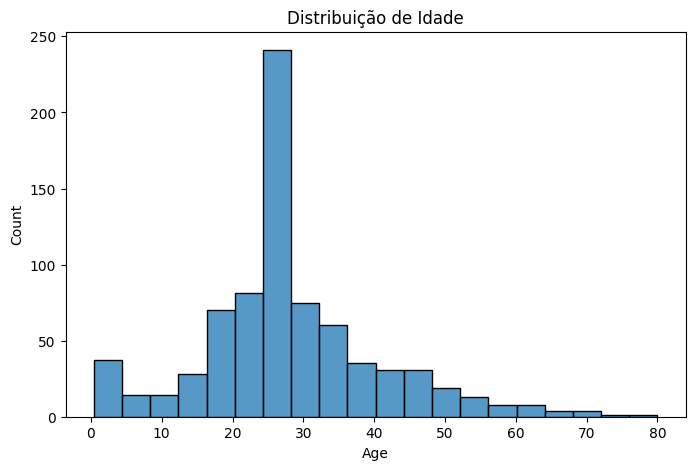

In [7]:

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title('Distribuição de Idade')
plt.show()


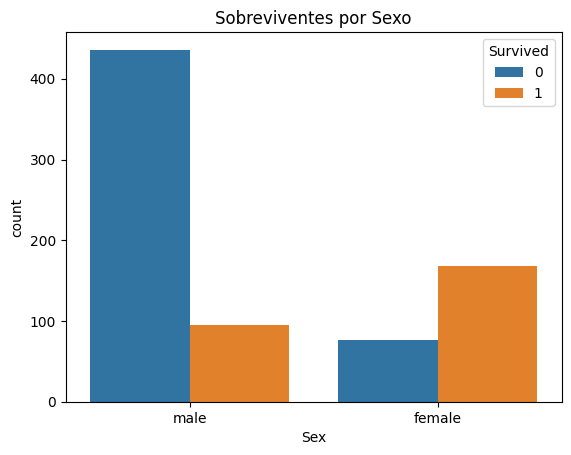

In [8]:

sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Sobreviventes por Sexo')
plt.show()


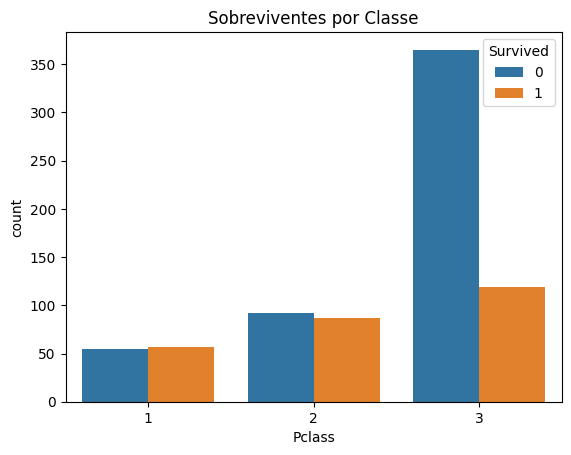

In [9]:

sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Sobreviventes por Classe')
plt.show()


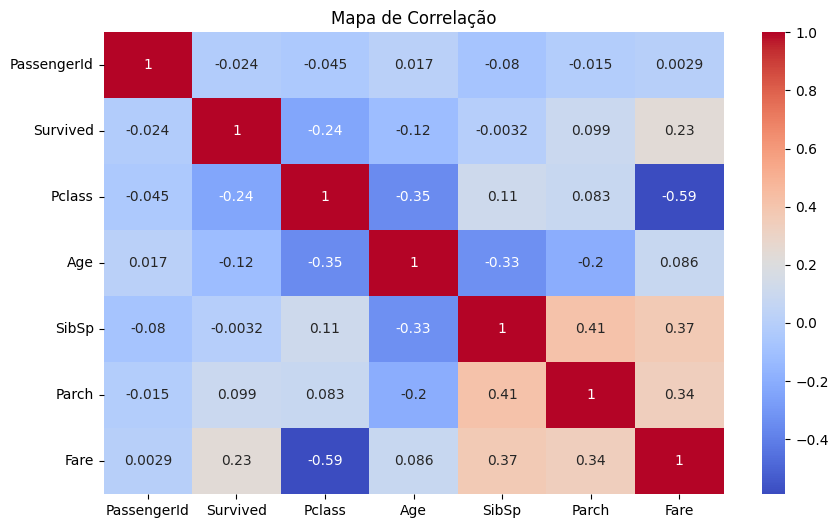

In [10]:

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()


## Teorema de Bayes Manual

In [11]:

p_survive = (df['Survived'] == 1).mean()

p_female_given_survive = (
    len(df[(df['Sex']=='female') & (df['Survived']==1)])
    / len(df[df['Survived']==1])
)

p_female = (df['Sex']=='female').mean()

bayes = (p_female_given_survive * p_survive) / p_female

print('P(Sobreviveu | Feminino) =', bayes)


P(Sobreviveu | Feminino) = 0.6885245901639345


## Preparação para Machine Learning

In [12]:

df_ml = df.copy()

df_ml['Sex'] = df_ml['Sex'].map({'male':0,'female':1})
df_ml['Embarked'] = df_ml['Embarked'].map({'S':0,'C':1,'Q':2})

df_ml = df_ml.drop(['Name','Ticket','PassengerId'], axis=1)

X = df_ml.drop('Survived', axis=1)
y = df_ml['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Árvore de Decisão

In [13]:

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_tree))
print("Precision:", precision_score(y_test, pred_tree))
print("Recall:", recall_score(y_test, pred_tree))
print("F1:", f1_score(y_test, pred_tree))
print(confusion_matrix(y_test, pred_tree))


Accuracy: 0.7741935483870968
Precision: 0.7272727272727273
Recall: 0.6666666666666666
F1: 0.6956521739130435
[[80 15]
 [20 40]]


## Random Forest

In [14]:

forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)

pred_forest = forest.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_forest))
print("Precision:", precision_score(y_test, pred_forest))
print("Recall:", recall_score(y_test, pred_forest))
print("F1:", f1_score(y_test, pred_forest))
print(confusion_matrix(y_test, pred_forest))


Accuracy: 0.7612903225806451
Precision: 0.7169811320754716
Recall: 0.6333333333333333
F1: 0.672566371681416
[[80 15]
 [22 38]]


## Comparação Final

In [15]:

resultado = pd.DataFrame({
    'Modelo':['Decision Tree','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,pred_tree),
        accuracy_score(y_test,pred_forest)
    ]
})

resultado


,Modelo,Accuracy
0,Decision Tree,0.774194
1,Random Forest,0.761290
